In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import learning_curve
from seaborn import heatmap


In [2]:
df=pd.read_csv("data/car_evaluation.tsv", sep='\t')
df

,buying_price,maintenance_costs,doors,seats,luggage_boot,safety,target
0,3,3,0,0,0,0,0
1,3,3,0,0,0,1,0
2,3,3,0,0,0,2,0
3,3,3,0,0,1,0,0
4,3,3,0,0,1,1,0
...,...,...,...,...,...,...,...
1723,0,0,3,2,1,1,2
1724,0,0,3,2,1,2,3
1725,0,0,3,2,2,0,0
1726,0,0,3,2,2,1,2


In [3]:
x_col= len(df.columns[:-1])

In [4]:
X = df.iloc[:, 0:x_col].values
print(X)


[[3 3 0 0 0 0]
 [3 3 0 0 0 1]
 [3 3 0 0 0 2]
 ...
 [0 0 3 2 2 0]
 [0 0 3 2 2 1]
 [0 0 3 2 2 2]]


In [5]:
y = df.iloc[:, -1].values
print(y)

[0 0 0 ... 0 2 3]


In [6]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=5)

In [8]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1382, 6)
(346, 6)
(1382,)
(346,)


In [9]:
from sklearn.preprocessing import StandardScaler
X_train_scaled = StandardScaler().fit_transform(X_train)
X_test_scaled = StandardScaler().fit_transform(X_test)

In [76]:
model=LogisticRegression(class_weight='balanced')
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [77]:
y_pred = model.predict(X_test_scaled)

In [78]:
train_sizes, train_scores, test_scores = learning_curve(
    model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='accuracy'
)

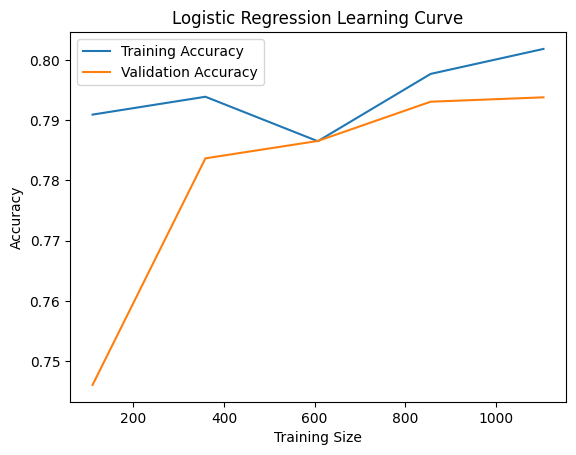

In [79]:

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.plot(train_sizes, train_mean, label='Training Accuracy')
plt.plot(train_sizes, test_mean, label='Validation Accuracy')

plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Logistic Regression Learning Curve")

plt.legend()
plt.savefig('Figure/logistic_learning_curve.pdf')
plt.show()

In [80]:

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[200  32  11   4]
 [ 20  52   3   4]
 [  0   0  10   0]
 [  0   1   0   9]]


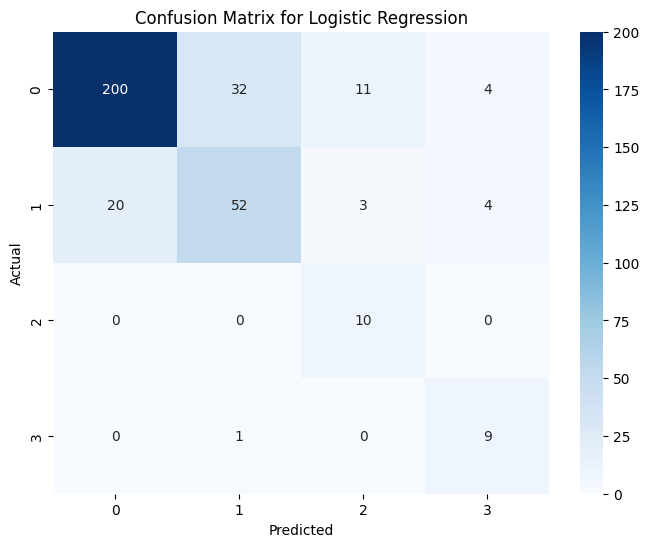

In [81]:
# plot cm with values in every cell
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('Figure/logistic_regression_confusion_matrix.pdf')
plt.show()

In [ ]:

report = classification_report(y_test, y_pred)
print(report)



              precision    recall  f1-score   support

           0       0.91      0.81      0.86       247
           1       0.61      0.66      0.63        79
           2       0.42      1.00      0.59        10
           3       0.53      0.90      0.67        10

    accuracy                           0.78       346
   macro avg       0.62      0.84      0.69       346
weighted avg       0.82      0.78      0.79       346



# KNN

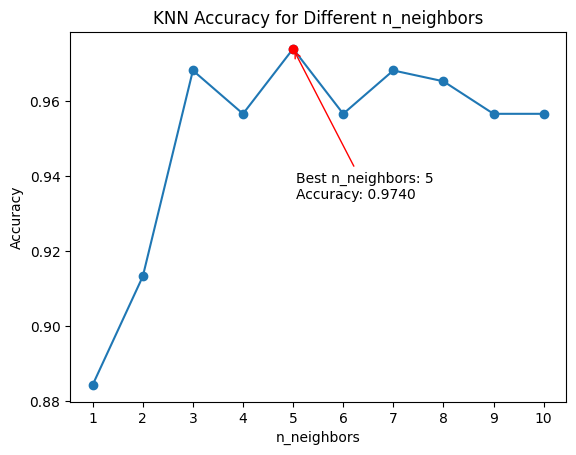

Best n_neighbors: 5 with accuracy: 0.9740


In [83]:
accuracy = {}

best_acc = 0
best_model = None
best_pred = None
best_k = 0

for k in range(1, 11):
    model2=KNeighborsClassifier(n_neighbors=k)
    model2.fit(X_train_scaled, y_train)
    y_pred2 = model2.predict(X_test_scaled)
    accuracy[k] = np.mean(y_pred2 == y_test)
    if accuracy[k] > best_acc:
        best_acc = accuracy[k]
        best_model = model2
        best_pred = y_pred2
        best_k = k

plt.plot(list(accuracy.keys()), list(accuracy.values()), marker='o')
plt.title('KNN Accuracy for Different n_neighbors')
plt.xlabel('n_neighbors')
plt.ylabel('Accuracy')
plt.xticks(range(1, 11))
plt.scatter(best_k, best_acc, color='red', zorder=5)
plt.annotate(f'Best n_neighbors: {best_k}\nAccuracy: {best_acc:.4f}', xy=(best_k, best_acc), xytext=(best_k + 0.05, best_acc - 0.04), arrowprops=dict(arrowstyle='->', color='red'))
plt.savefig('Figure/knn_accuracy.pdf')
plt.show()

print(f"Best n_neighbors: {best_k} with accuracy: {best_acc:.4f}")

In [ ]:

report = classification_report(y_test, best_pred)
print(report)

KNN

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       247
           1       0.96      0.92      0.94        79
           2       1.00      1.00      1.00        10
           3       1.00      1.00      1.00        10

    accuracy                           0.97       346
   macro avg       0.98      0.98      0.98       346
weighted avg       0.97      0.97      0.97       346



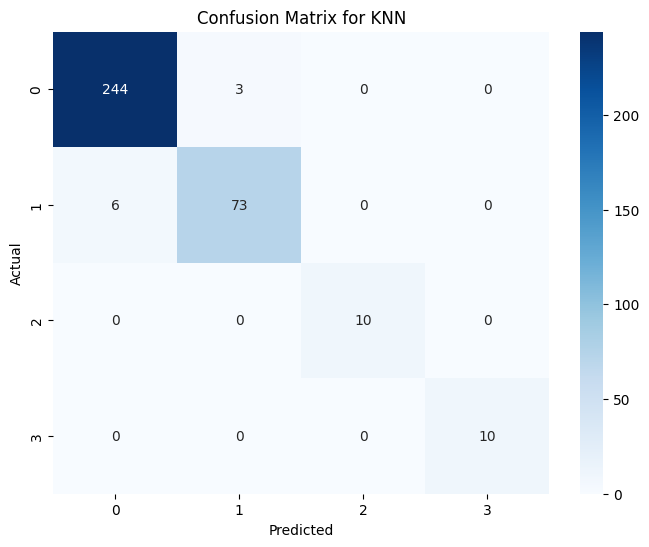

In [85]:

cm = confusion_matrix(y_test, best_pred)
# plot cm with values in every cell
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for KNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('Figure/kn_confusion_matrix.pdf')
plt.show()